<a href="https://colab.research.google.com/github/chilesh07/Deeplearning/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification Dog & Cat & Person

In [27]:
import torch
import os
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset ,DataLoader

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# !unzip '/content/drive/MyDrive/Colab Notebooks/Classification_dataset_v3.zip'

Archive:  /content/drive/MyDrive/Colab Notebooks/Classification_dataset_v3.zip
   creating: Classification_dataset_v3/
  inflating: Classification_dataset_v3/Dataset_info.txt  
   creating: Classification_dataset_v3/images/
   creating: Classification_dataset_v3/images/test/
   creating: Classification_dataset_v3/images/test/Cat/
  inflating: Classification_dataset_v3/images/test/Cat/cat_1000.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1001.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1002.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1003.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1004.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1005.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1006.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1007.jpg  
  inflating: Classification_dataset_v3/images/test/Cat/cat_1008.jpg  
  inflating: Classification_dataset_v3

In [8]:
image_dir =  '/content/Classification_dataset_v3/images/train'
for label, class_dir in enumerate(os.listdir(image_dir)):
  print(label,class_dir)

0 person
1 Cat
2 Dog


In [9]:

class ImageDataset(Dataset):

    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_paths = []
        self.labels = []
        self.class_names = {}
        self.transform = transform

        for label, class_dir in enumerate(os.listdir(image_dir)):
            self.class_names[label] = class_dir
            class_path = os.path.join(image_dir, class_dir)

            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)

                self.image_paths.append(img_path)
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


In [10]:
transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# mean = [0.485,0.456,0.406],std=[0.229,0.224,0.225]

In [11]:
train_image_dir = '/content/Classification_dataset_v3/images/train'
test_image_dir = '/content/Classification_dataset_v3/images/test'

train_image_dataset = ImageDataset(image_dir=train_image_dir, transform=transforms)
test_image_dataset = ImageDataset(image_dir=test_image_dir, transform=transforms)

In [12]:
train_image_loader=DataLoader(dataset=train_image_dataset,batch_size= 32 ,shuffle = True)
test_image_loader =DataLoader(dataset=test_image_dataset,batch_size= 32 ,shuffle = True)

In [13]:
for images,labels in train_image_loader:
  print(images.shape,labels.shape)

torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([32, 3, 128, 128]) torch.Size([32])
torch.Size([3

In [14]:
import matplotlib.pyplot as plt
import numpy as np

In [15]:
print(train_image_dataset.class_names)
print(test_image_dataset.class_names)

{0: 'person', 1: 'Cat', 2: 'Dog'}
{0: 'person', 1: 'Cat', 2: 'Dog'}


torch.Size([32, 3, 128, 128]) torch.Size([32])
(3, 128, 128)
person
(128, 128, 3)
0


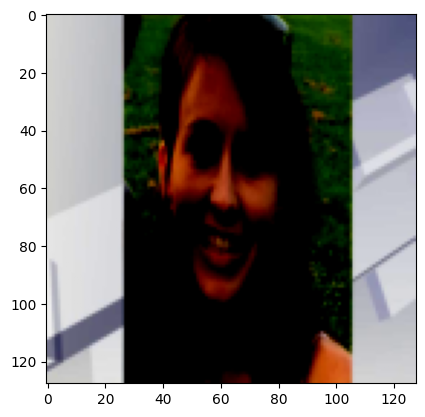

In [20]:
for images, labels in train_image_loader:
  print(images.shape,labels.shape)
  img=images[0].numpy()
  print(img.shape)
  label=labels[0].item()
  print(train_image_dataset.class_names[label])
  img = np.transpose(img, (1, 2, 0))
  print(img.shape)
  print(label)
  plt.imshow(img,vmin = 0 , vmax = 255)
  plt.show()
  break

# CNN Architecture

1. convolution
2. stride
3. padding
4. Max pooling
5. batch Normalization  
6. Activation funcation
7. functional layes

In [16]:
import torch.nn as nn
import torch.optim as optim

In [17]:
from IPython.utils.py3compat import no_code
class CustomCnnModel(nn.Module):
  def __init__(self,input_dim,num_classes):
    super(CustomCnnModel,self).__init__()
    self.input_dim = input_dim
    self.num_classes =  num_classes

    # Convolution layers
    self.conv_layers = nn.Sequential(
        # C1
        nn.Conv2d(3, 32, kernel_size= 3, stride=1 ,padding=1 ), # rgb =  3  # grey = 1
        # 128X128X3 --> 3X3X3X32 --> wxhx32
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C2
        nn.Conv2d(32, 64, kernel_size= 3, stride=1 ,padding=1 ),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C3
        nn.Conv2d(64, 128, kernel_size= 3, stride=1 ,padding=1 ),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C4
        nn.Conv2d(128, 256, kernel_size= 3, stride=1 ,padding=1 ),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)

    )
    self._to_linear = None
    self._get_conv_output(self.input_dim)

    self.fc_layers= nn.Sequential(
        nn.Linear(self._to_linear,512),
        nn.ReLU(),
        nn.Linear(512,128),
        nn.ReLU(),
        nn.Linear(128,self.num_classes)

    )
    ## 256 X 12 X 12

  def _get_conv_output(self,input_dim):
    with torch.no_grad():
      dummy_input =torch.zeros(1,3,input_dim, input_dim) # Modified to take a 4D input for Conv2d
      output = self.conv_layers(dummy_input)
      self.to_linear = output.view(1,-1).size(1)
      self._to_linear = self.to_linear # Assign to _to_linear


  def forward(self,x):
    x = self.conv_layers(x)
    x = x.view(x.size(0),-1)
    x = self.fc_layers(x)
    return x

In [18]:
# Initialize  Model

device = torch.device('cuda'if torch.cuda.is_available() else 'cpu')
model = CustomCnnModel(input_dim=128,num_classes=3).to(device)
print(model)
print(device)

CustomCnnModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [23]:
# Training Loop

epochs = 2
for epoch in range(epochs):
  model.train()
  running_loss = 0.0 ## starting from zero ## Loss rate
  for images,labels in train_image_loader:
    images,labels = images.to(device),labels.to(device)
    optimizer.zero_grad()
    output = model(images)
    loss =criterion(output,labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  print(f"Epoch{epoch+1}/{epochs},Loss:{running_loss/len(train_image_loader)}")

Epoch1/2,Loss:0.8779475111710398
Epoch2/2,Loss:0.5792516331923635


In [21]:
torch.save(model.state_dict(),"Cnn_model.pth")

In [22]:
# Evaluate model

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images,labels in test_image_loader:
    images,labels = images.to(device), labels.to(device)
    output = model(images)
    _, predicted = torch.max(output,1) # Unpack the tuple and get the predicted indices
    total += labels.size(0) # Add the batch size to total
    correct += (predicted == labels).sum().item() # Compare predicted indices with labels and call .item() as a function
print(f"Test accuracy is : {100*correct / total:.2f}%")

Test accuracy is : 25.00%


In [30]:
import cv2

In [34]:
class ImageClassifier:
    def __init__(self,model_path,class_names):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = CustomCnnModel(input_dim=128,num_classes=3).to(self.device)
        self.model.load_state_dict(torch.load(model_path,map_location=self.device))
        self.model.eval()
        self.class_names = class_names
        self.transforms = transforms.Compose([
            transforms.Resize((128,128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])])

    def predict(self,image_paths):
      image =Image.open(image_paths).convert('RGB')
      input_tensor = self.transforms(image).unsqueeze(0).to(self.device)
      with torch.no_grad():
        output = self.model(input_tensor)
        _, predicted = torch.max(output,1)
        label = self.class_names[predicted.item()]
        img = cv2.imread(image_paths)
        cv2.putText(img,label,(10,30),cv2.FONT_HERSHEY_SCRIPT_COMPLEX,1,(0,255,0),2)
        cv2.imwrite('output_image.jpg',img)
      return label

In [35]:
classifier = ImageClassifier('/content/Cnn_model.pth',train_image_dataset.class_names)
label = classifier.predict('/content/Classification_dataset_v3/images/test/Dog/dog_1005.jpg')
print(f"predicted class is :{label}")

predicted class is :Dog
